# 06 — Breakout backtest (walk-forward)

**Question:** standing at the end of season *t*, using only what was known then, can we rank young players by their chance of breaking out (next season) or becoming a star (within 3 seasons)?

**Walk-forward rules** (`unicorn.backtest.walk_forward`):
1. Predictions for test season *t* use features from seasons ≤ *t* (all feature columns are built that way and were leakage-tested in 03).
2. A training row from season *s* is usable only if its **outcome was already known** at the end of *t*: *s* + horizon ≤ *t*. So *s* ≤ *t*−1 for next-season breakouts and *s* ≤ *t*−3 for star-within-3.
3. Imputation and scaling are fitted on those training rows only.

**Population:** every player aged ≤ 25 in season *t*, whatever his minutes, draft slot or status. For the star outcome, players already in the top 10% of the star score are excluded.

**Metrics:** breakouts are rare (1–7%), so accuracy is meaningless. We report **average precision** (area under the precision-recall curve; random = the base rate), its **lift** over random, ROC-AUC, and the per-season hit rate among the **top 10** and the share of breakouts caught in the **top 25**.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from unicorn.backtest import evaluate, feature_columns, logistic_model, per_season_ap, rule, walk_forward
from unicorn.labels import add_future, add_labels, add_star_score
from unicorn.plotting import apply_style, BLUE, ORANGE, INK, INK2, MUTED, FIG_DIR, SERIES, SURFACE
from unicorn.raw import PROJECT_ROOT

warnings.filterwarnings("ignore", category=RuntimeWarning)
apply_style()
uni = pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "player_season_unicorn.parquet")
BREAKOUTS = ["breakout_any", "breakout_scoring", "breakout_role", "breakout_production"]
lab = add_future(add_star_score(add_labels(uni)), BREAKOUTS, horizon=1)
lab = add_future(lab, ["star_season"], horizon=3)
FEATURES = feature_columns(lab)
print(len(FEATURES), "candidate features")

197 candidate features


### Models

| Model | What it is |
|---|---|
| random | coin flip, the floor |
| youngest first | rank by age only |
| rule of thumb | +1 for each of: age ≤ 23, usage rising, efficiency ≥ average, minutes rising, < 28 min/game (room to grow) |
| current star score | rank by this season's star score (from 05) |
| logistic (12) | L2 logistic regression on 12 hand-picked, interpretable signals |
| logistic (all) | L2 logistic regression on all 197 candidate features (level, trajectory, career, position, unicorn, pillars) |

In [2]:
SMALL = ["age", "min_per_game_z", "usg_pct_z", "ts_pct_shr_z", "star_score", "usg_pct_z_delta", "min_per_game_z_delta",
         "pct_uast_fgm_z", "ast_pct_z", "fta_rate_z", "draft_pick_filled", "pie_z_delta"]

class SmallLogistic:
    def __init__(self):
        self.model = logistic_model(C=1.0)
    def fit(self, X, y):
        self.model.fit(X[SMALL], y); return self
    def predict_proba(self, X):
        return self.model.predict_proba(X[SMALL])

rng = np.random.default_rng(0)
MODELS = {
    "random": rule(lambda d: rng.random(len(d))),
    "youngest first": rule(lambda d: -d["age"]),
    "rule of thumb": rule(lambda d: (d["age"] <= 23).astype(int) + (d["usg_pct_z_delta"] > 0) + (d["ts_pct_shr_z"] >= 0)
                          + (d["min_per_game_z_delta"] > 0) + (d["min_per_game"] < 28) + 0.01 * d["usg_pct_z"].fillna(0)),
    "current star score": rule(lambda d: d["star_score"].fillna(-9)),
    "logistic (12)": SmallLogistic,
    "logistic (all)": logistic_model,
}
young = lab["age"] <= 25
TARGETS = {  # target: (horizon, population, first test season, last test season with observable outcome)
    "breakout_any_next1": (1, young, 2014, 2024),
    "breakout_scoring_next1": (1, young, 2014, 2024),
    "breakout_role_next1": (1, young, 2014, 2024),
    "breakout_production_next1": (1, young, 2014, 2024),
    "star_season_next3": (3, young & (lab["star_pctl"].fillna(0) < 0.9), 2016, 2022),
}
preds, results = {}, {}
for target, (h, pop, first, last) in TARGETS.items():
    preds[target] = walk_forward(lab, target, h, pop, first, last, MODELS, FEATURES)
    results[target] = evaluate(preds[target])
summary = pd.concat(results, names=["target", "model"])
summary[["positives", "base_rate", "ROC_AUC", "avg_precision", "AP_lift", "precision@10", "recall@25"]].round(3)

positives  base_rate  ROC_AUC  \
target                    model                                               
breakout_any_next1        logistic (all)            178      0.069    0.795   
                          logistic (12)             178      0.069    0.786   
                          current star score        178      0.069    0.728   
                          rule of thumb             178      0.069    0.687   
                          youngest first            178      0.069    0.598   
                          random                    178      0.069    0.492   
breakout_scoring_next1    logistic (12)             126      0.049    0.873   
                          logistic (all)            126      0.049    0.862   
                          current star score        126      0.049    0.811   
                          rule of thumb             126      0.049    0.721   
                          youngest first            126      0.049    0.588   
                          random                    126      0.049    0.519   
breakout_role_next1       logistic (all)             79      0.031    0.756   
                          logistic (12)              79      0.031    0.689   
                          rule of thumb              79      0.031    0.623   
                          current star score         79      0.031    0.632   
                          youngest first             79      0.031    0.599   
                          random                     79      0.031    0.544   
breakout_production_next1 current star score         28      0.011    0.724   
                          logistic (all)             28      0.011    0.759   
                          logistic (12)              28      0.011    0.801   
                          rule of thumb              28      0.011    0.667   
                          youngest first             28      0.011    0.539   
                          random                     28      0.011    0.407   
star_season_next3         current star score         26      0.016    0.915   
                          logistic (12)              26      0.016    0.874   
                          logistic (all)             26      0.016    0.833   
                          random                     26      0.016    0.626   
                          rule of thumb              26      0.016    0.697   
                          youngest first             26      0.016    0.621   

                                              avg_precision  AP_lift  \
target                    model                                        
breakout_any_next1        logistic (all)              0.235    3.401   
                          logistic (12)               0.207    2.995   
                          current star score          0.158    2.292   
                          rule of thumb               0.131    1.902   
                          youngest first              0.090    1.309   
                          random                      0.068    0.977   
breakout_scoring_next1    logistic (12)               0.234    4.791   
                          logistic (all)              0.218    4.460   
                          current star score          0.147    3.014   
                          rule of thumb               0.107    2.192   
                          youngest first              0.062    1.257   
                          random                      0.053    1.090   
breakout_role_next1       logistic (all)              0.075    2.432   
                          logistic (12)               0.062    2.032   
                          rule of thumb               0.057    1.861   
                          current star score          0.043    1.407   
                          youngest first              0.042    1.382   
                          random                      0.037    1.207   
breakout_production_next1 current star score          0.082    7.498   
     

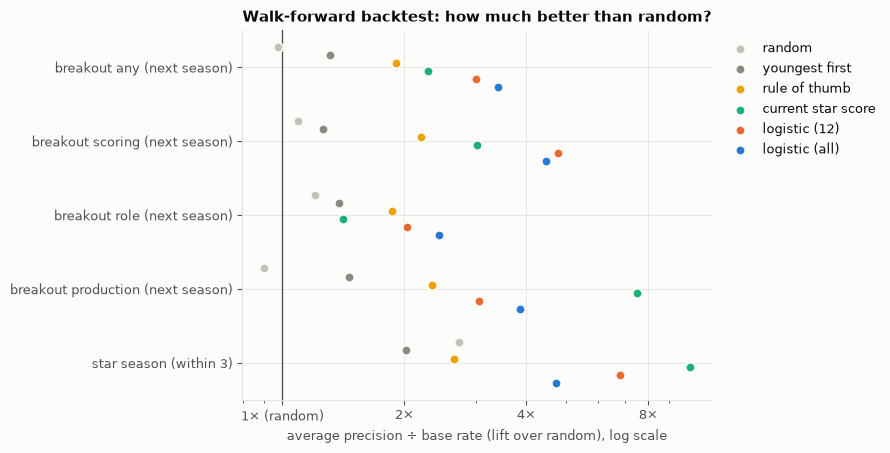

In [3]:
order = ["random", "youngest first", "rule of thumb", "current star score", "logistic (12)", "logistic (all)"]
colors = dict(zip(order, [MUTED, "#8a8984", SERIES[3], SERIES[2], SERIES[1], SERIES[0]]))
targets = list(TARGETS)
fig, ax = plt.subplots(figsize=(9, 4.6))
for i, m in enumerate(order):
    lifts = [results[t].loc[m, "AP_lift"] for t in targets]
    ax.scatter(lifts, np.arange(len(targets)) + (i - 2.5) * 0.11, s=46, color=colors[m], edgecolor=SURFACE, linewidth=1.2, label=m, zorder=3)
ax.axvline(1, color=INK2, linewidth=1)
ax.set_yticks(range(len(targets)), [t.replace("_next1", " (next season)").replace("_next3", " (within 3)").replace("_", " ") for t in targets])
ax.invert_yaxis(); ax.set_xscale("log"); ax.set_xticks([1, 2, 4, 8], ["1× (random)", "2×", "4×", "8×"])
ax.set_xlabel("average precision ÷ base rate (lift over random), log scale")
ax.legend(frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_title("Walk-forward backtest: how much better than random?", loc="left")
fig.tight_layout(); fig.savefig(FIG_DIR / "06_backtest_lift.png", dpi=150, bbox_inches="tight")

### Is it stable season to season? (any breakout, next season)

model,current star score,logistic (12),logistic (all),random,rule of thumb,youngest first
test_season,,,,,,
2014,0.240,0.159,0.222,0.069,0.152,0.120
2015,0.414,0.306,0.264,0.216,0.345,0.206
2016,0.226,0.331,0.399,0.142,0.230,0.206
2017,0.268,0.203,0.227,0.090,0.213,0.117
2018,0.281,0.409,0.446,0.085,0.172,0.113
2019,0.223,0.258,0.265,0.087,0.135,0.123
2020,0.133,0.231,0.252,0.054,0.125,0.091
2021,0.106,0.190,0.176,0.037,0.087,0.039
2022,0.089,0.135,0.308,0.040,0.083,0.058


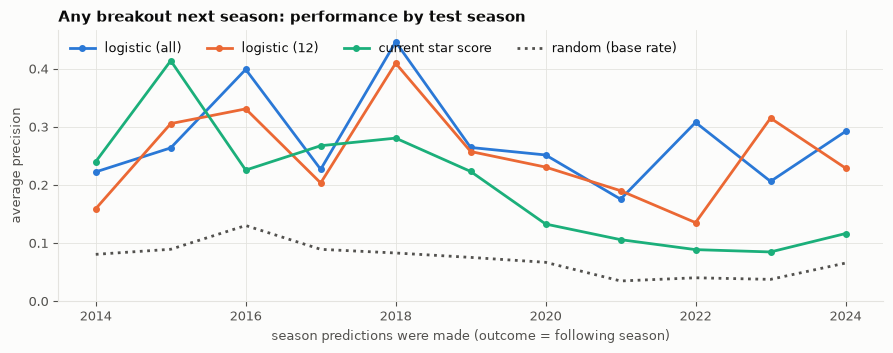

In [4]:
ap = per_season_ap(preds["breakout_any_next1"])
base = preds["breakout_any_next1"].groupby("test_season")["outcome"].mean()
fig, ax = plt.subplots(figsize=(9, 3.6))
for m in ["logistic (all)", "logistic (12)", "current star score"]:
    ax.plot(ap.index, ap[m], color=colors[m], marker="o", markersize=4, label=m)
ax.plot(base.index, base, color=INK2, linestyle=":", label="random (base rate)")
ax.set_ylabel("average precision"); ax.set_xlabel("season predictions were made (outcome = following season)")
ax.legend(frameon=False, ncol=4, loc="upper left"); ax.set_ylim(0, None)
ax.set_title("Any breakout next season: performance by test season", loc="left")
fig.tight_layout(); fig.savefig(FIG_DIR / "06_backtest_by_season.png", dpi=150, bbox_inches="tight")
ap.round(3)

### What would we actually have said?

Top 12 young players by predicted breakout probability (logistic, all features), with what actually happened the next season.

In [5]:
L = preds["breakout_any_next1"].query("model == 'logistic (all)'")
for t in [2018, 2020, 2024]:
    g = L[L["test_season"] == t].nlargest(12, "score")
    print(f"End of {t}-{(t + 1) % 100:02d}: hits {g['outcome'].sum()}/12 (base rate {L[L['test_season'] == t]['outcome'].mean():.0%})")
    display(g[["player_name", "score", "outcome"]].round(2).reset_index(drop=True))

End of 2018-19: hits 6/12 (base rate 8%)


,player_name,score,outcome
0,Giannis Antetokounmpo,0.69,1
1,Brandon Ingram,0.56,1
2,Domantas Sabonis,0.52,1
3,Kevon Looney,0.52,0
4,Kelly Oubre Jr.,0.50,1
5,Julius Randle,0.47,0
6,Jayson Tatum,0.46,1
7,Devin Booker,0.46,0
8,Nikola Jokić,0.38,0
9,Jarrett Allen,0.37,0


End of 2020-21: hits 3/12 (base rate 7%)


,player_name,score,outcome
0,Jayson Tatum,0.66,1
1,Talen Horton-Tucker,0.52,0
2,Michael Porter Jr.,0.52,0
3,Isaiah Hartenstein,0.48,0
4,Luka Dončić,0.37,0
5,Bam Adebayo,0.35,0
6,Keldon Johnson,0.33,1
7,Kevin Porter Jr.,0.33,0
8,Terance Mann,0.32,0
9,Domantas Sabonis,0.31,0


End of 2024-25: hits 4/12 (base rate 7%)


,player_name,score,outcome
0,Dyson Daniels,0.59,0
1,Christian Braun,0.59,0
2,Deni Avdija,0.50,1
3,Anthony Black,0.47,1
4,Jalen Williams,0.45,0
5,Ryan Rollins,0.41,1
6,Jalen Duren,0.37,1
7,Coby White,0.37,0
8,Cade Cunningham,0.33,0
9,Anthony Edwards,0.32,0


In [6]:
ranked = L.assign(rank=L.groupby("test_season")["score"].rank(ascending=False), of=L.groupby("test_season")["score"].transform("size"))
ranked[ranked["player_name"].isin(["Shai Gilgeous-Alexander", "LaMelo Ball"])][["player_name", "season", "score", "rank", "of", "outcome"]].round(3)

,player_name,season,score,rank,of,outcome
5995,Shai Gilgeous-Alexander,2018-19,0.176,37.0,229,1
7428,Shai Gilgeous-Alexander,2019-20,0.360,12.0,252,1
8903,Shai Gilgeous-Alexander,2020-21,0.236,22.0,254,1
9028,LaMelo Ball,2020-21,0.266,18.0,254,0
10564,Shai Gilgeous-Alexander,2021-22,0.209,32.0,287,1
10664,LaMelo Ball,2021-22,0.384,10.0,287,0
12072,Shai Gilgeous-Alexander,2022-23,0.253,23.0,248,0
12130,LaMelo Ball,2022-23,0.315,16.0,248,0
13673,LaMelo Ball,2023-24,0.096,56.0,266,0
15206,LaMelo Ball,2024-25,0.036,111.0,259,0


### What does the simple model look at?

Standardized coefficients of the 12-signal logistic model, fitted on **all observable outcomes up to 2024-25**. This is for interpretation only; the backtest refits it every season.

age                    -0.42
draft_pick_filled      -0.24
usg_pct_z              -0.21
pie_z_delta            -0.06
fta_rate_z             -0.01
ast_pct_z               0.11
ts_pct_shr_z            0.11
pct_uast_fgm_z          0.18
min_per_game_z_delta    0.25
star_score              0.30
usg_pct_z_delta         0.33
min_per_game_z          0.49
dtype: float64

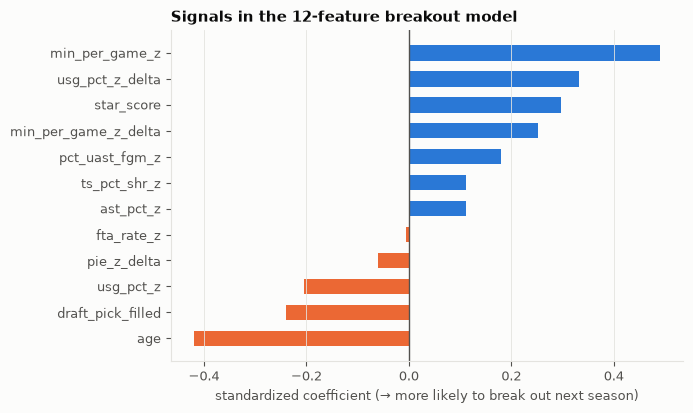

In [7]:
obs = lab[young & lab["observable_next1"]]
m = SmallLogistic().fit(obs, obs["breakout_any_next1"].astype(int))
lr = m.model.named_steps["logisticregression"]
coef = pd.Series(lr.coef_[0][:len(SMALL)], index=SMALL).sort_values()
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.barh(coef.index, coef.values, color=np.where(coef > 0, BLUE, ORANGE), height=0.6)
ax.axvline(0, color=INK2, linewidth=1); ax.grid(axis="y", visible=False)
ax.set_xlabel("standardized coefficient (→ more likely to break out next season)")
ax.set_title("Signals in the 12-feature breakout model", loc="left")
fig.tight_layout(); fig.savefig(FIG_DIR / "06_small_model_coefficients.png", dpi=150, bbox_inches="tight")
coef.round(2)

### Step 6 findings (first backtest, 2014-15 → 2024-25 predictions)

**Breakouts are partly predictable from information available at the time.**

| Outcome | Base rate | Best model | Average precision | Lift | Top-10 hit rate |
|---|---|---|---|---|---|
| Any breakout | 6.9% | logistic (all) | 0.235 | **3.4×** | 34% |
| Scoring breakout | 4.9% | logistic (12) | 0.234 | **4.8×** | 29% |
| Role breakout | 3.1% | logistic (all) | 0.075 | 2.4× | 6% |
| Production breakout | 1.1% | current star score | 0.082 | 7.5× | 5% |
| Star within 3 seasons | 1.6% | current star score | 0.160 | **10×** | 16% |

- **The simple model is nearly as good as the complex one.** For "any breakout", 12 interpretable signals reach AP 0.207 vs 0.235 with all 197 features, and the 12-signal model wins on scoring breakouts.
- **For becoming a star, nothing beats current quality yet.** The star score on its own (10× lift, catching 74% of future stars in each season's top 25) beats both logistic models. With only 26 positive cases, extra features overfit.
- **Production and star results are noisy** (28 and 26 positives; even random reaches 2.8× on stars by chance). They need confidence intervals before we read much into them.
- **Every season beats random**, though the models' advantage over "current star score" has *grown* in recent seasons (2020+).
- **What predicts a breakout** (12-signal model): already getting minutes, usage rising, minutes rising, a high current star score, self-creation, efficiency, passing. *Against*: being older, a later draft pick, and already having high usage (less room to grow).
- **Shai:** ranked **37th of 229** after his rookie year (he broke out, but outside the top 25), then **12th** after year 2 and 22nd after year 3, so the model caught on once the trajectory appeared. **LaMelo:** ranked 10th–18th in his first three seasons but never had a single-season jump; his steady growth isn't what these labels count.
- **Example:** at the end of 2018-19 the model's top 12 contained 6 breakouts (Giannis, Ingram, Sabonis, Oubre, Tatum, Fox) vs an 8% base rate.

**Next improvements:** bootstrap confidence intervals; tune regularization with an inner time-respecting split; try tree-based models; probability calibration; then apply to current players (07).

## Step 6B — Strengthening the backtest

1. **Confidence intervals:** cluster bootstrap that resamples whole players (500×), paired across models so differences between models get their own interval.
2. **Tuning without peeking:** `TunedLogistic` chooses its regularization on the *most recent season inside the training window*, then refits. The test season is never involved.
3. **Two new model families:** **boosted trees** (shallow, heavily regularized gradient boosting, which can learn interactions like "young AND rising usage") and **nearest comps** (k = 40 most similar historical player-seasons on 18 profile features; probability = their weighted breakout rate). If comps work here, the "players like Dëmin" analysis in 07 has been tested, not just asserted.
4. **Calibration:** when a model says 30%, do about 30% break out?

In [8]:
from sklearn.metrics import brier_score_loss
from unicorn.backtest import NearestComps, TunedLogistic, boosted_trees, bootstrap_ap

MODELS_B = {"current star score": MODELS["current star score"], "logistic (12)": SmallLogistic,
            "logistic (all)": logistic_model, "logistic tuned": TunedLogistic,
            "boosted trees": boosted_trees, "nearest comps": NearestComps}
preds_b, boot, draws = {}, {}, {}
for target in ["breakout_any_next1", "breakout_scoring_next1", "star_season_next3"]:
    h, pop, first, last = TARGETS[target]
    preds_b[target] = walk_forward(lab, target, h, pop, first, last, MODELS_B, FEATURES)
    boot[target], draws[target] = bootstrap_ap(preds_b[target], n_boot=500, return_draws=True)
pd.concat(boot, names=["target", "model"]).round(2)

AP_lift  ci_low  ci_high
target                 model                                       
breakout_any_next1     boosted trees          4.18    3.28     5.31
                       logistic (all)         3.40    2.52     4.56
                       logistic tuned         3.06    2.47     3.98
                       logistic (12)          3.00    2.41     3.92
                       nearest comps          2.64    2.20     3.39
                       current star score     2.29    1.77     3.11
breakout_scoring_next1 boosted trees          6.10    4.89     7.96
                       logistic (12)          4.79    3.93     6.36
                       logistic (all)         4.46    3.53     5.88
                       logistic tuned         4.33    3.37     5.81
                       nearest comps          4.10    3.34     5.31
                       current star score     3.01    2.41     4.04
star_season_next3      current star score    10.15    6.66    22.99
                       logistic (12)          6.83    3.80    16.69
                       nearest comps          4.98    1.49    18.67
                       logistic (all)         4.73    2.70    10.54
                       boosted trees          4.21    2.35     9.49
                       logistic tuned         3.41    1.98     7.69

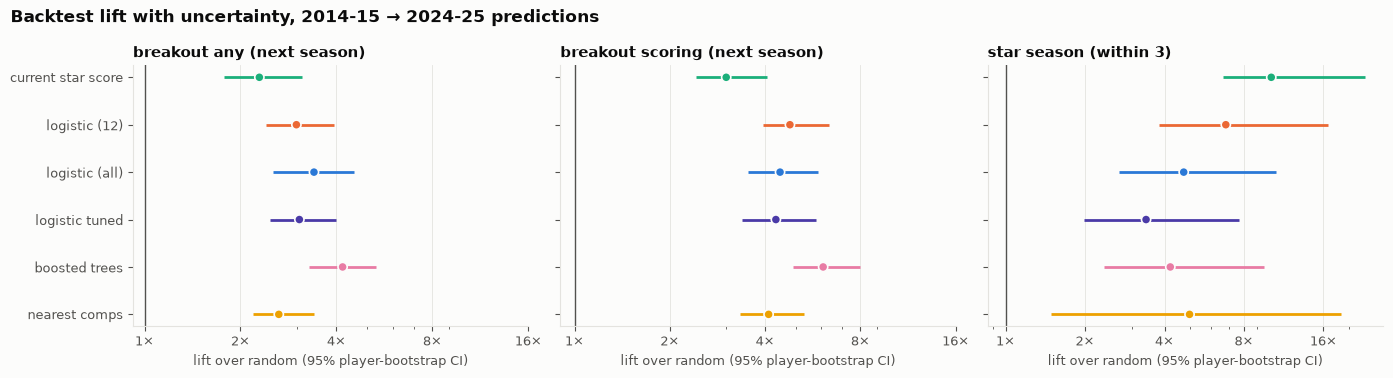

In [9]:
colors_b = {"current star score": SERIES[2], "logistic (12)": SERIES[1], "logistic (all)": SERIES[0],
            "logistic tuned": "#4a3aa7", "boosted trees": "#e87ba4", "nearest comps": SERIES[3]}
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)
model_order = list(MODELS_B)
for ax, (target, b) in zip(axes, boot.items()):
    b = b.reindex(model_order)
    y = np.arange(len(b))
    ax.hlines(y, b["ci_low"], b["ci_high"], color=[colors_b[m] for m in b.index], linewidth=2)
    ax.scatter(b["AP_lift"], y, color=[colors_b[m] for m in b.index], s=44, edgecolor=SURFACE, linewidth=1.2, zorder=3)
    ax.axvline(1, color=INK2, linewidth=1)
    ax.set_xscale("log"); ax.set_xticks([1, 2, 4, 8, 16], ["1×", "2×", "4×", "8×", "16×"])
    ax.set_title(target.replace("_next1", " (next season)").replace("_next3", " (within 3)").replace("_", " "), loc="left")
    ax.grid(axis="y", visible=False)
axes[0].set_yticks(range(len(model_order)), model_order); axes[0].invert_yaxis()
for ax in axes:
    ax.set_xlabel("lift over random (95% player-bootstrap CI)")
fig.suptitle("Backtest lift with uncertainty, 2014-15 → 2024-25 predictions", x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout(); fig.savefig(FIG_DIR / "06_backtest_lift_ci.png", dpi=150, bbox_inches="tight")

### Are the differences between models real? (paired bootstrap, lift difference)

In [10]:
def paired(target, a, b):
    d = draws[target][a] - draws[target][b]
    return {"target": target, "comparison": f"{a} − {b}", "difference": d.mean(),
            "ci_low": np.percentile(d, 2.5), "ci_high": np.percentile(d, 97.5), "P(a > b)": (d > 0).mean()}

pd.DataFrame([paired("breakout_any_next1", "boosted trees", "logistic (all)"),
              paired("breakout_any_next1", "logistic (all)", "logistic (12)"),
              paired("breakout_any_next1", "nearest comps", "current star score"),
              paired("breakout_scoring_next1", "logistic (12)", "boosted trees"),
              paired("star_season_next3", "current star score", "logistic (all)"),
              paired("star_season_next3", "current star score", "nearest comps")]).round(2)

,target,comparison,difference,ci_low,ci_high,P(a > b)
0,breakout_any_next1,boosted trees − logistic (all),0.79,-0.01,1.66,0.97
1,breakout_any_next1,logistic (all) − logistic (12),0.35,-0.46,1.14,0.82
2,breakout_any_next1,nearest comps − current star score,0.34,-0.21,0.84,0.91
3,breakout_scoring_next1,logistic (12) − boosted trees,-1.26,-2.75,0.05,0.03
4,star_season_next3,current star score − logistic (all),6.32,2.30,14.41,1.00
5,star_season_next3,current star score − nearest comps,5.46,-5.66,15.54,0.88


### Calibration: do the probabilities mean what they say? (any breakout, next season)

,Brier,Brier (base rate only)
model,,
logistic (all),0.0615,0.0643
boosted trees,0.0565,0.0643
nearest comps,0.0610,0.0643


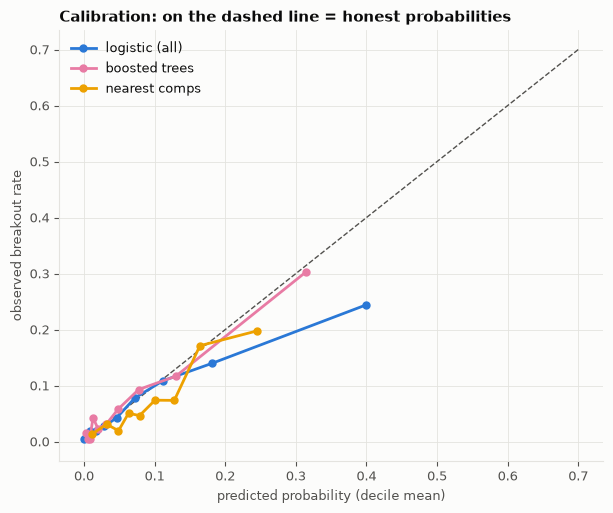

In [11]:
fig, ax = plt.subplots(figsize=(6.2, 5.2))
ax.plot([0, 0.7], [0, 0.7], color=INK2, linewidth=1, linestyle="--")
cal_rows = []
for m in ["logistic (all)", "boosted trees", "nearest comps"]:
    g = preds_b["breakout_any_next1"].query("model == @m").copy()
    g["bin"] = pd.qcut(g["score"], 10, duplicates="drop")
    c = g.groupby("bin", observed=True).agg(predicted=("score", "mean"), observed=("outcome", "mean"))
    ax.plot(c["predicted"], c["observed"], color=colors_b[m], marker="o", markersize=5, label=m)
    cal_rows.append({"model": m, "Brier": brier_score_loss(g["outcome"], g["score"]),
                     "Brier (base rate only)": brier_score_loss(g["outcome"], np.full(len(g), g["outcome"].mean()))})
ax.set_xlabel("predicted probability (decile mean)"); ax.set_ylabel("observed breakout rate")
ax.legend(frameon=False, loc="upper left")
ax.set_title("Calibration: on the dashed line = honest probabilities", loc="left")
fig.tight_layout(); fig.savefig(FIG_DIR / "06_calibration.png", dpi=150, bbox_inches="tight")
pd.DataFrame(cal_rows).set_index("model").round(4)

### Step 6B findings

- **Boosted trees are the best breakout model:** any breakout **4.2× (95% CI 3.3–5.3)**, scoring breakout **6.1× (4.9–8.0)**. The paired comparison with logistic (all) on any breakout gives +0.8 lift, CI (−0.01, 1.66), better in 97% of bootstrap draws: likely real but borderline. Trees are also the best calibrated (Brier 0.0565 vs 0.0643 for the base rate alone). Logistic regression is overconfident at the top: when it says 40%, about 24% break out.
- **Simple vs complex logistic:** no reliable difference (12 vs 197 features, P(all > 12) = 0.82).
- **Tuning on the last training season didn't help** (3.1× vs 3.4× untuned): one validation season is too noisy to choose settings. A fixed, conservative regularization is fine.
- **Nearest comps work, modestly:** 2.6× for any breakout and 4.1× for scoring, better than the current star score (P = 0.91) but behind the trained models. They're good enough to *explain* a player ("players like him did X"), not to be the main forecast.
- **Becoming a star:** the current star score clearly beats logistic (all) (+6.3 lift, CI 2.3–14.4). Every model has very wide intervals (26 positives). **For star potential, current all-round quality relative to peers is the most reliable signal we have.**

**Decision for 07 (D19):** breakout probabilities from **boosted trees**; star potential from the **current star score** (rank), with the 12-signal logistic as a second view; **nearest comps** for explanation.

## Step 6C — Sensitivity to minutes thresholds

Two places where a minimum-minutes choice could change the conclusions:

**(a) Who we make predictions for.** Restrict the population (and its training data) to players with ≥ 0 / 250 / 500 / 1,000 minutes in season *t*. Does ranking quality change, and how many future breakouts and stars fall outside the restricted pool?

**(b) What counts as a breakout season.** A breakout season must have ≥ 1,200 minutes (scaled to 82 games). Re-label with 900 and 1,500 and rerun.

In [12]:
M_SENS = {"boosted trees": boosted_trees, "current star score": MODELS["current star score"]}
first, last = 2014, 2024
in_window = young & lab["season_start"].between(first, last)
all_breakouts = lab.loc[in_window & lab["observable_next1"], "breakout_any_next1"].sum()
all_stars = lab.loc[young & (lab["star_pctl"].fillna(0) < 0.9) & lab["season_start"].between(2016, 2022) & lab["star_season_next3"]]

rows = []
for thr in [0, 250, 500, 1000]:
    pop = young & (lab["min"] >= thr)
    P = walk_forward(lab, "breakout_any_next1", 1, pop, first, last, M_SENS, FEATURES)
    e = evaluate(P)
    rows.append({"min_minutes": thr, "player_seasons": int(e.loc["boosted trees", "n"]),
                 "breakouts_kept": P.query("model == 'boosted trees'")["outcome"].sum() / all_breakouts,
                 "future_stars_kept": (all_stars["min"] >= thr).mean(),
                 "base_rate": e.loc["boosted trees", "base_rate"], "lift_trees": e.loc["boosted trees", "AP_lift"],
                 "top10_hit_trees": e.loc["boosted trees", "precision@10"], "top10_hit_star_score": e.loc["current star score", "precision@10"]})
pop_sens = pd.DataFrame(rows).set_index("min_minutes")
pop_sens.round(3)

,player_seasons,breakouts_kept,future_stars_kept,base_rate,lift_trees,top10_hit_trees,top10_hit_star_score
min_minutes,,,,,,,
0,2576,1.000,1.000,0.069,4.182,0.391,0.200
250,1813,0.966,1.000,0.095,3.019,0.382,0.218
500,1505,0.949,0.885,0.112,2.715,0.400,0.218
1000,1075,0.831,0.808,0.138,2.314,0.355,0.227


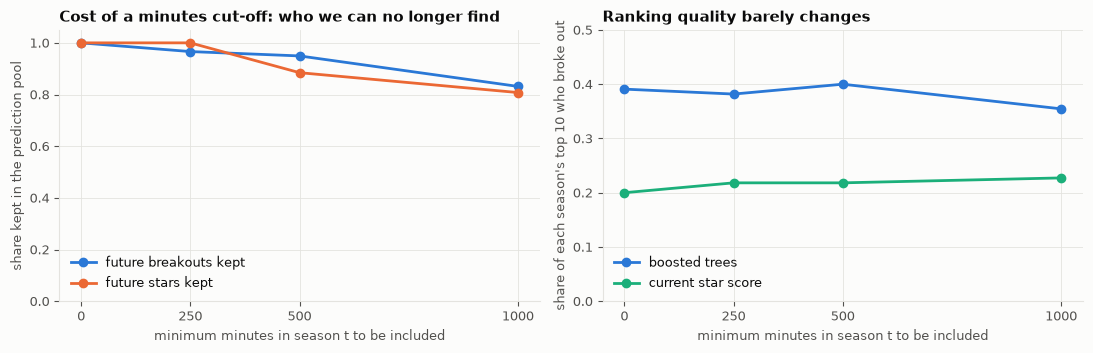

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharex=True)
x = pop_sens.index
axes[0].plot(x, pop_sens["breakouts_kept"], color=BLUE, marker="o", label="future breakouts kept")
axes[0].plot(x, pop_sens["future_stars_kept"], color=ORANGE, marker="o", label="future stars kept")
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel("share kept in the prediction pool")
axes[0].set_title("Cost of a minutes cut-off: who we can no longer find", loc="left")
axes[0].legend(frameon=False, loc="lower left")
axes[1].plot(x, pop_sens["top10_hit_trees"], color=BLUE, marker="o", label="boosted trees")
axes[1].plot(x, pop_sens["top10_hit_star_score"], color=SERIES[2], marker="o", label="current star score")
axes[1].set_ylim(0, 0.5); axes[1].set_ylabel("share of each season's top 10 who broke out")
axes[1].set_title("Ranking quality barely changes", loc="left")
axes[1].legend(frameon=False, loc="lower left")
for ax in axes:
    ax.set_xticks(list(x)); ax.set_xlabel("minimum minutes in season t to be included")
fig.tight_layout(); fig.savefig(FIG_DIR / "06_minutes_threshold_sensitivity.png", dpi=150, bbox_inches="tight")

In [14]:
rows = []
for real_min in [900, 1200, 1500]:
    l2 = add_future(add_star_score(add_labels(uni, real_season_min=real_min)), ["breakout_any"], horizon=1)
    P = walk_forward(l2, "breakout_any_next1", 1, l2["age"] <= 25, first, last, M_SENS, FEATURES)
    e = evaluate(P)
    rows.append({"breakout_season_min": real_min, "base_rate": e.loc["boosted trees", "base_rate"],
                 "MIP_captured": int(l2.loc[l2["mip"], "breakout_any"].sum()),
                 "lift_trees": e.loc["boosted trees", "AP_lift"], "lift_star_score": e.loc["current star score", "AP_lift"],
                 "top10_hit_trees": e.loc["boosted trees", "precision@10"]})
pd.DataFrame(rows).set_index("breakout_season_min").round(3)

,base_rate,MIP_captured,lift_trees,lift_star_score,top10_hit_trees
breakout_season_min,,,,,
900,0.075,12,3.576,2.095,0.418
1200,0.069,12,4.182,2.292,0.391
1500,0.062,12,4.372,2.502,0.345


### Step 6C findings

- **A minutes cut-off doesn't improve the ranking, it only shrinks the pool.** The top-10 hit rate for boosted trees is 39% / 38% / 40% / 36% at 0 / 250 / 500 / 1,000 minutes. Lift over random falls (4.2× → 2.3×) only because low-minute players are easy negatives.
- **But it does lose future successes:**
  - a 500-minute cut-off loses 5% of next-season breakouts and **12% of future stars**;
  - a 1,000-minute cut-off loses 17% and **19%**.
- **Conclusion: no minimum-minutes filter on who we predict for.** Keep everyone ("anyone can become a star"); the models already use minutes as a feature.
- **The breakout definition's minutes requirement doesn't matter much.** At 900 / 1,200 / 1,500 minutes, lift is 3.6× / 4.2× / 4.4× and all three capture the same 12 Most Improved winners. The conclusions don't hinge on 1,200.